# Roxy tutorial: sequence feature engineering and AAIndex integration

This notebook demonstrates how to use **Roxy** to:

- Build a `RoxyDataset` from a simple table of protein sequences and labels.
- Compute global sequence descriptors (composition, hydrophobicity, charge, etc.).
- Enrich the representation with **AAIndex-based descriptors**.
- Combine feature blocks into a single matrix suitable for machine learning.
- Visualise the resulting feature space using PCA.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from roxy.core.dataset import RoxyDataset
from roxy.core.aaindex import load_aaindex, ensure_aaindex_available
from roxy.descriptors.sequences import ProteinDescriptorError, GlobalSequenceDescriptors

## 1. Ensure AAIndex data is available

The AAIndex CSV will be downloaded to the Roxy cache directory on first use
if it is not already present.

In [2]:
# Ensure AAIndex CSV is available (downloads on first call if missing)
ensure_aaindex_available()

aaindex_table = load_aaindex()
aaindex_table.head()

,ANDN920101,ARGP820101,ARGP820102,ARGP820103,BEGF750101,BEGF750102,BEGF750103,BHAR880101,BIGC670101,BIOV880101,...,KARS160113,KARS160114,KARS160115,KARS160116,KARS160117,KARS160118,KARS160119,KARS160120,KARS160121,KARS160122
residue,,,,,,,,,,,,,,,,,,,,,
A,4.35,0.61,1.18,1.56,1.00,0.77,0.37,0.357,52.6,16.0,...,6.0,6.00,6.0,6.0,12.0,6.00,12.000,0.0,6.000,0.000
C,4.65,1.07,1.89,1.23,0.06,0.65,0.84,0.346,68.3,168.0,...,6.0,16.67,12.0,22.0,28.0,9.33,28.000,0.0,11.333,6.000
D,4.76,0.46,0.05,0.14,0.44,0.65,0.97,0.511,68.4,-78.0,...,12.0,16.40,12.0,20.0,34.0,6.80,28.634,0.0,10.400,2.969
E,4.29,0.47,0.11,0.23,0.73,0.55,0.53,0.497,84.7,-106.0,...,12.0,21.00,14.0,26.0,40.0,6.67,28.731,0.0,10.667,1.822
F,4.66,2.02,1.96,2.03,0.60,0.98,0.53,0.314,113.9,189.0,...,18.0,23.25,18.0,24.0,48.0,6.00,26.993,0.0,12.000,2.026


## 2. Create a toy dataset of sequences with labels

We create a small synthetic dataset with two classes:

- `basic`: sequences enriched in positively charged residues (K/R).
- `acidic`: sequences enriched in negatively charged residues (D/E).

In [3]:
toy_data = {
    "sequence": [
        "KKKKKKKKKKAAAAAA",   # basic-rich
        "RRRRRRRRRRVVVVVV",
        "KKRRKKRRKKRRKKRR",
        "DDDDDDDDDDGGGGGG",   # acidic-rich
        "EEEEEEEEEEAAAAAA",
        "DDEEDDDEEDDEEDD",
    ],
    "label": [
        "basic",
        "basic",
        "basic",
        "acidic",
        "acidic",
        "acidic",
    ],
    "id": [
        "prot_1",
        "prot_2",
        "prot_3",
        "prot_4",
        "prot_5",
        "prot_6",
    ],
}

samples_df = pd.DataFrame(toy_data).set_index("id")
samples_df

,sequence,label
id,,
prot_1,KKKKKKKKKKAAAAAA,basic
prot_2,RRRRRRRRRRVVVVVV,basic
prot_3,KKRRKKRRKKRRKKRR,basic
prot_4,DDDDDDDDDDGGGGGG,acidic
prot_5,EEEEEEEEEEAAAAAA,acidic
prot_6,DDEEDDDEEDDEEDD,acidic


## 3. Wrap the samples and labels into a `RoxyDataset`

In [4]:
ds = RoxyDataset(
    samples=samples_df[["sequence"]],   # raw sequence modality
    y=samples_df["label"],              # labels (basic / acidic)
    metadata={"task_type": "classification", "name": "toy_charge_dataset"},
    name="toy_roxy_demo",
)

ds

<RoxyDataset(name='toy_roxy_demo', n_samples=6, n_raw_columns=1)
  feature_blocks: none
  has_y: True>

## 4. Global sequence descriptors (without AAIndex)

We use `GlobalSequenceDescriptors`, which internally relies on the
low-level `ProteinDescriptorError` backend, to compute global features
such as composition, hydrophobicity, charge, etc.

In [5]:
# Instantiate the engine with default settings
engine_global = GlobalSequenceDescriptors(pH=7.0, include_histidine_in_charge=False)

# Compute features for all samples
X_global = engine_global.compute(ds.samples)

# Register this block in the dataset under the key 'seq_global'
ds.add_features("seq_global", X_global)

print("Feature blocks:", ds.feature_blocks)
X_global.head()

Feature blocks: ['seq_global']


,length,aa_frac_M,aa_frac_I,aa_frac_V,aa_frac_Y,aa_frac_F,aa_frac_W,aa_frac_P,aa_frac_A,aa_frac_L,...,boman_index,net_charge_pH,fcr,ncpr,donors_per_residue,acceptors_per_residue,aa_entropy,lc_k1,lc_k2,lc_k3
_index,,,,,,,,,,,,,,,,,,,,,
prot_1,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,-0.55500,9.994823,0.625,0.624676,0.625,0.000,0.954434,0.125,0.200000,0.285714
prot_2,16.0,0.0,0.0,0.375,0.0,0.0,0.0,0.0,0.000,0.0,...,-0.60500,9.997953,0.625,0.624872,0.625,0.000,0.954434,0.125,0.200000,0.285714
prot_3,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,-1.00000,15.995430,1.000,0.999714,1.000,0.000,1.000000,0.125,0.266667,0.285714
prot_4,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,-0.76500,-9.994777,0.625,-0.624674,0.000,0.625,0.954434,0.125,0.200000,0.285714
prot_5,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,-1.19875,-9.984264,0.625,-0.624017,0.000,0.625,0.954434,0.125,0.200000,0.285714


## 5. AAIndex-based descriptors

Now we enrich the representation with mean AAIndex properties for each
sequence. The AAIndex table contains many indices; for the sake of the
example we will select a small subset of codes.

We will:

1. Choose a few AAIndex codes.
2. Use `ProteinDescriptorError.featurize_df` with `aaindex_codes`.
3. Keep **only** the `aaindex_*` columns to avoid column name clashes
   with the global descriptors.
4. Register this second block as `seq_aaindex` in the dataset.


In [6]:
# 1. Choose a few AAIndex codes (here: the first 5 columns)
available_codes = list(aaindex_table.columns)
selected_codes = available_codes[:5]
selected_codes

['ANDN920101', 'ARGP820101', 'ARGP820102', 'ARGP820103', 'BEGF750101']

In [7]:
# 2. Compute descriptors including AAIndex-based features
X_full_aaindex = ProteinDescriptorError.featurize_df(
    ds.samples,
    sequence_col="sequence",
    aaindex_codes=selected_codes,
)

X_full_aaindex.head()

,length,aa_frac_M,aa_frac_I,aa_frac_V,aa_frac_Y,aa_frac_F,aa_frac_W,aa_frac_P,aa_frac_A,aa_frac_L,...,acceptors_per_residue,aa_entropy,lc_k1,lc_k2,lc_k3,aaindex_ANDN920101_mean,aaindex_ARGP820101_mean,aaindex_ARGP820102_mean,aaindex_ARGP820103_mean,aaindex_BEGF750101_mean
prot_1,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,0.000,0.954434,0.125,0.200000,0.285714,4.35625,0.94750,0.48000,0.67875,0.75000
prot_2,16.0,0.0,0.0,0.375,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000,0.954434,0.125,0.200000,0.285714,4.21875,0.87000,0.53000,0.70875,0.63250
prot_3,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000,1.000000,0.125,0.266667,0.285714,4.37000,0.87500,0.13000,0.30000,0.56000
prot_4,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,0.625,0.954434,0.125,0.200000,0.285714,4.46375,0.31375,0.21500,0.32000,0.40625
prot_5,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,0.625,0.954434,0.125,0.200000,0.285714,4.31250,0.52250,0.51125,0.72875,0.83125


In [8]:
# 3. Keep only AAIndex columns (avoid overlapping with 'seq_global')
aa_cols = [c for c in X_full_aaindex.columns if c.startswith("aaindex_")]
X_aaindex = X_full_aaindex[aa_cols]

# 4. Register this block as 'seq_aaindex'
ds.add_features("seq_aaindex", X_aaindex)

print("Feature blocks:", ds.feature_blocks)
X_aaindex.head()

Feature blocks: ['seq_global', 'seq_aaindex']


,aaindex_ANDN920101_mean,aaindex_ARGP820101_mean,aaindex_ARGP820102_mean,aaindex_ARGP820103_mean,aaindex_BEGF750101_mean
prot_1,4.35625,0.94750,0.48000,0.67875,0.75000
prot_2,4.21875,0.87000,0.53000,0.70875,0.63250
prot_3,4.37000,0.87500,0.13000,0.30000,0.56000
prot_4,4.46375,0.31375,0.21500,0.32000,0.40625
prot_5,4.31250,0.52250,0.51125,0.72875,0.83125


## 6. Combine feature blocks into a single matrix

We now merge the `seq_global` and `seq_aaindex` blocks into a single
feature matrix `X_all`, aligned with the labels `y`.

In [9]:
X_all, y = ds.to_Xy(feature_keys=["seq_global", "seq_aaindex"])

print("X_all shape:", X_all.shape)
X_all.head()

X_all shape: (6, 46)


,length,aa_frac_M,aa_frac_I,aa_frac_V,aa_frac_Y,aa_frac_F,aa_frac_W,aa_frac_P,aa_frac_A,aa_frac_L,...,acceptors_per_residue,aa_entropy,lc_k1,lc_k2,lc_k3,aaindex_ANDN920101_mean,aaindex_ARGP820101_mean,aaindex_ARGP820102_mean,aaindex_ARGP820103_mean,aaindex_BEGF750101_mean
id,,,,,,,,,,,,,,,,,,,,,
prot_1,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,0.000,0.954434,0.125,0.200000,0.285714,4.35625,0.94750,0.48000,0.67875,0.75000
prot_2,16.0,0.0,0.0,0.375,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000,0.954434,0.125,0.200000,0.285714,4.21875,0.87000,0.53000,0.70875,0.63250
prot_3,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,0.000,1.000000,0.125,0.266667,0.285714,4.37000,0.87500,0.13000,0.30000,0.56000
prot_4,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.000,0.0,...,0.625,0.954434,0.125,0.200000,0.285714,4.46375,0.31375,0.21500,0.32000,0.40625
prot_5,16.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.375,0.0,...,0.625,0.954434,0.125,0.200000,0.285714,4.31250,0.52250,0.51125,0.72875,0.83125


## 7. PCA visualisation of the feature space

We perform a PCA on `X_all` and plot the first two principal components,
colouring points by their class label (`basic` vs `acidic`).

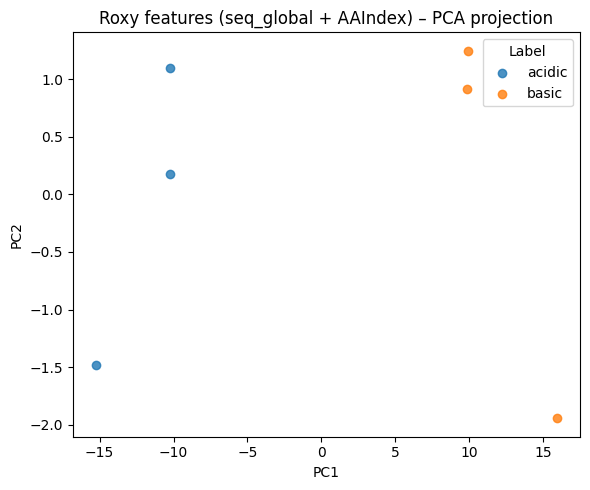

In [10]:
# Ensure no NaNs before PCA
X_for_pca = X_all.fillna(0.0)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

labels = y.values
unique_labels = np.unique(labels)

plt.figure(figsize=(6, 5))
for lab in unique_labels:
    mask = labels == lab
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=str(lab),
        alpha=0.8,
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Roxy features (seq_global + AAIndex) – PCA projection")
plt.legend(title="Label")
plt.tight_layout()
plt.show()